<h2 align="center"> State changes - Visual Behavior Neuropixels </h2>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p> During the task, the mice are visually engaged, interact with their environment, and portray several behavioral profile sequences. Meanwhile, Neuropixels electrodes record spiking activity across the visual cortex and several hippocampal and thalamic nuclei. The behavioral task, therefore, offers an opportunity to study the dynamics of spiking activity during various behavioral states and aids in understanding the behavioral dynamics of task engagement.     
</div>

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from scipy.stats import norm
import seaborn as sns
import glob

pd.set_option('display.max_columns', None)

%matplotlib inline

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p> The <a href="https://portal.brain-map.org/explore/circuits/visual-behavior-neuropixels">Visual Behavior Neuropixels dataset</a> consists of recordings of neural activity measured using 6 Neuropixels probes from mice that have learned to perform an image change detection task.  Recordings are made simultaneously from neurons distributed across layers in the visual cortex ( VISp, VISl, VISal, VISrl, VISam, and VISpm), neurons in the hippocampus (CA1/3, DG), and neurons in the visual thalamus (LP and LGd).
    
<p> In this go/no-go task task, mice are shown a series of visual images that are briefly presented (250 ms) and they earn water rewards by correctly reporting (licking the reward spout) when the identity of the image changes (diagrammed below). 
     
</div>

<img src="Resources/download.png">  

In [2]:
from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorNeuropixelsProjectCache

cache_dir  =  "/data/"

cache = VisualBehaviorNeuropixelsProjectCache.from_local_cache(cache_dir=cache_dir, use_static_cache=True)


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
    
The Visual Behavior Neuropixels dataset is accessed with the Python module `VisualBehaviorNeuropixelsProjectCache`. Path to the NWBs that store the session information from all mice are also provided.
    
</div>

In [3]:
# 1053709239, 1090803859, 1112515874, 1115368723,  1152632711 
example_sessions = [1139846596,  1124507277, 1069461581, 1064644573, 1067790400, 1093642839, 1130113579 ]

session_id = example_sessions[0] 
session = cache.get_ecephys_session(session_id)

trial_metadata = session.trials # 'trials' is a dataframe that contains metadata and task information for each trial

/opt/conda/lib/python3.9/site-packages/hdmf/spec/namespace.py:531: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.8.0 because version 1.5.1 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/opt/conda/lib/python3.9/site-packages/hdmf/spec/namespace.py:531: UserWarning: Ignoring cached namespace 'core' version 2.6.0-alpha because version 2.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/opt/conda/lib/python3.9/site-packages/hdmf/spec/namespace.py:531: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.5.0 because version 0.2.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


In [4]:
stim_table = session.stimulus_presentations
stim_table = stim_table[stim_table['trials_id'] != -1] # clean up 

# Merge the two DataFrames based on trial index
merged_df = trial_metadata.drop(columns=['lick_times']).merge(
    stim_table,
    left_index=True,         # Use the index of trial_metadata as the join key
    right_on='trials_id',    # Use the 'trials_id' column of stim_table as the join key
    how='outer',             # Default join type, adjust as needed
)

# Resolve overlapping columns by choosing from trial_metadata (e.g., `_x`) or stim_table (e.g., `_y`)
for col in trial_metadata.columns.intersection(stim_table.columns):
    merged_df[col] = merged_df[f"{col}_y"].combine_first(merged_df[f"{col}_x"])
    merged_df.drop(columns=[f"{col}_x", f"{col}_y"], inplace=True)

merged_df = merged_df.rename(columns={'stop_time': 'trial_stop_time'})
merged_df = merged_df.sort_values(by='start_time', ascending = True)
stim_table_concat = merged_df

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
How well does the mouse recognize a change in the image sequences? We can quantify their performance by evaluating the fraction of 'go' trials during which the mouse licked the spout.      
</div>

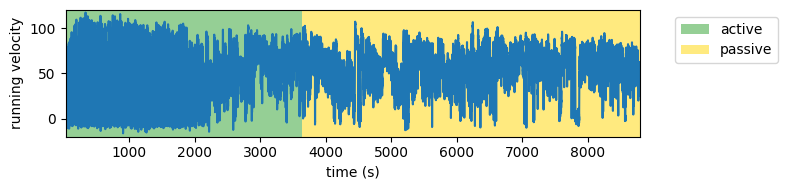

In [5]:
# Get running speed and corresponding timestamps
running_time = session.running_speed.timestamps
running_speed = session.running_speed.speed

stop_time = stim_table_concat.start_time.max()
start_time = stim_table_concat.start_time.min()


# Plot running speed
fig,ax = plt.subplots( figsize = (8, 2)) 
ax.plot(running_time, running_speed)
    
# Formatting
ax.set_xlim(start_time, stop_time)
ax.set_ylim(-20, 120)
ax.set_xlabel('time (s)')
ax.set_ylabel('running velocity');

active_start = stim_table_concat[stim_table_concat.active].start_time.values[0]
active_end = stim_table_concat[stim_table_concat.active].start_time.values[-1]

# Plot boundaries to mark state transitions
ax.axvspan(active_start, active_end, facecolor='tab:green', alpha=0.5, label = 'active')
ax.axvspan(active_end, stop_time, facecolor='gold', alpha=0.5, label = 'passive')
plt.legend(bbox_to_anchor = (1.05, 1))
plt.tight_layout()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
<p> To avoid the effect of licking on behavioral movements, lets look only at the pre-change period. 
</div>

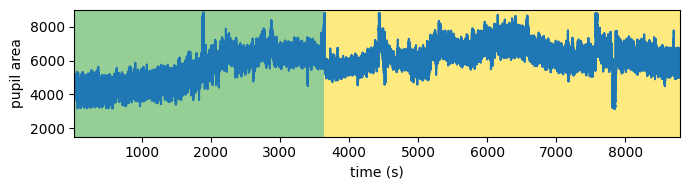

In [6]:
# Get pupil size and associated timestamps
pupil_time = session.eye_tracking.timestamps
pupil_area = session.eye_tracking.pupil_area

# Plot pupil size
fig,ax = plt.subplots(figsize = (7, 2))
ax.plot(pupil_time, pupil_area)

# Formatting
ax.set_xlim(start_time, stop_time)
ax.set_ylim(1500, 9000)
ax.set_xlabel('time (s)')
ax.set_ylabel('pupil area')


# Plot boundaries to mark state transitions
ax.axvspan(active_start, active_end, facecolor='tab:green', alpha=0.5, label = 'active')
ax.axvspan(active_end, stop_time, facecolor='gold', alpha=0.5, label = 'passive')

plt.tight_layout()

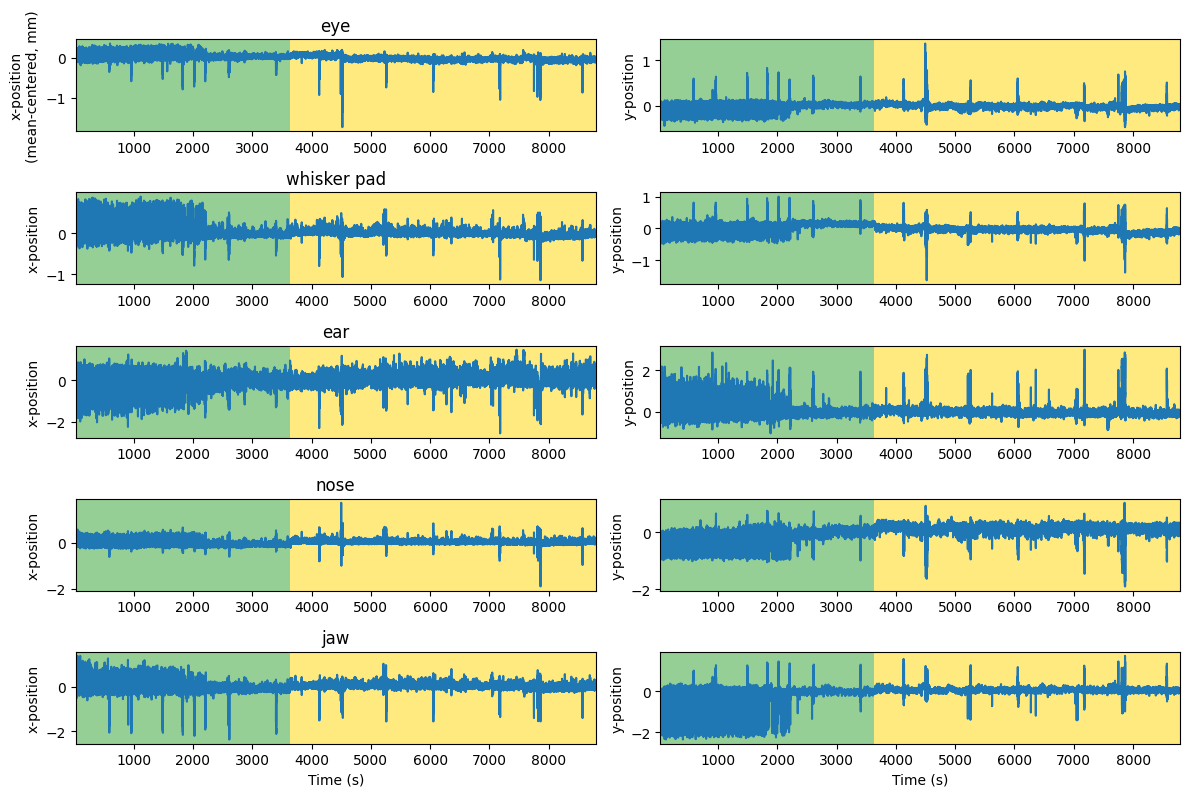

In [7]:
# facial expressions
from scipy.signal import savgol_filter

def part_info_LP(part_name, df, temp_norm):

    confidence = df[part_name , 'likelihood'].values.astype('float')
    x_c = df[part_name , 'x'].values.astype('float')
    y_c = df[part_name , 'y'].values.astype('float')
    xy_c = np.sqrt(x_c ** 2 + (492-y_c) ** 2)

    x_c[(confidence < 0.99) | (temp_norm > np.nanmean(temp_norm) + 2 * np.nanstd(temp_norm))] = np.nan
    x = pd.Series(x_c).interpolate(limit_direction='both').to_numpy()
    
    y_c[(confidence < 0.99) | (temp_norm > np.nanmean(temp_norm) + 2 * np.nanstd(temp_norm))] = np.nan
    y = 492 - pd.Series(y_c).interpolate(limit_direction='both').to_numpy()
    
    xy_c[(confidence < 0.99) | (temp_norm > np.nanmean(temp_norm) + 2 * np.nanstd(temp_norm))] = np.nan
    xy = pd.Series(xy_c).interpolate(limit_direction='both').to_numpy()
    
    return savgol_filter(x, 11, 3), savgol_filter(y, 11, 3), savgol_filter(xy, 11, 3)
    

pose_tracking_path = '/root/capsule/data/pose_tracking/outputs/video_preds/'

face_keys = ['eye_bottom_l','whisker_pad_l_side', 'ear_base_l', 'nose_tip', 'jaw']
part_names = ['eye', 'whisker pad', 'ear', 'nose', 'jaw']

# Read the CSV file
df_pose_tracking = pd.read_csv(glob.glob(f'{pose_tracking_path}/{session_id}*behavior.csv')[0], header=[0, 1, 2])
df_pose_tracking = df_pose_tracking.droplevel(0, axis=1)

temporal_norm = pd.read_csv(glob.glob(f'{pose_tracking_path}/{session_id}*norm.csv')[0])

# get timestamps for video
timestamps_path = '/root/capsule/data/VBN_video_timestamps/'
timestamps = np.load(glob.glob(f'{timestamps_path}/{session_id}*side.npy')[0])

# Print the keys to check the new MultiIndex
fig, ax = plt.subplots(len(face_keys), 2, figsize = (12, 8))
for kno, key_name in enumerate(face_keys): 
    x, y, xy = part_info_LP(key_name, df_pose_tracking, temporal_norm[key_name].values)
    x, y = x*0.242, y*0.242 # convert to mm
    x = x - np.nanmean(x)
    y = y - np.nanmean(y)
    
    ax[kno, 0].plot(timestamps, x)
    ax[kno, 1].plot(timestamps, y)
    
    # Formatting
    ax[kno, 0].set_xlim(start_time, stop_time)
    ax[kno, 1].set_xlim(start_time, stop_time)

    if kno == 0:
        ax[kno, 0].set_ylabel('x-position\n(mean-centered, mm)')
    else: 
        ax[kno, 0].set_ylabel('x-position')
    ax[kno, 1].set_ylabel('y-position')
    ax[kno, 0].set_title(f'{part_names[kno]}', loc='center', fontsize=12)
    ax[kno, 0].axvspan(active_start, active_end, facecolor='tab:green', alpha=0.5, label = 'active')
    ax[kno, 0].axvspan(active_end, stop_time, facecolor='gold', alpha=0.5, label = 'passive')
    
    ax[kno, 1].axvspan(active_start, active_end, facecolor='tab:green', alpha=0.5, label = 'active')
    ax[kno, 1].axvspan(active_end, stop_time, facecolor='gold', alpha=0.5, label = 'passive')
    

ax[len(face_keys)-1, 0].set_xlabel('Time (s)')
ax[len(face_keys)-1, 1].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()